# Set up

In [15]:
import pandas as pd
import os
import matplotlib as plt

from surprise import Reader, AlgoBase, Dataset, accuracy
from surprise.model_selection import train_test_split
import numpy as np
from collections import defaultdict
import recmetrics
from sklearn.metrics import ndcg_score

from sklearn.preprocessing import StandardScaler

from surprise.model_selection import cross_validate, KFold

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.preprocessing import normalize

In [16]:
SEED = 42; TOP_K = 10; RELEVANCE_THRESHOLD = 7; MIN_ITEM_RATINGS = 500
N_USERS = 5000; N_USERS_COVERAGE = 300

np.random.seed(SEED)
ratings_df = pd.read_csv("../processed_data/explicit_ratings.csv")

# We shuffle the users
all_users = ratings_df["user_id"].unique()
np.random.shuffle(all_users)

# Readers for our ranking (implemented wide as some ratings go above 10. Showed improvement!)
reader      = Reader(rating_scale=(1, 10))
reader_wide = Reader(rating_scale=(1, 20))

# We sample the 5000 users
sample = ratings_df[ratings_df["user_id"].isin(all_users[:N_USERS])][["user_id", "anime_id", "rating"]]
data = Dataset.load_from_df(sample, reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=SEED) # Normal 80/20 split

# For coverage, we are using only 300 people as the matrix with 6000 catalog items would be 1.8M predictions and not 30M with 5k users.
sample_cov = ratings_df[ratings_df["user_id"].isin(all_users[:N_USERS_COVERAGE])][["user_id", "anime_id", "rating"]]
data_cov = Dataset.load_from_df(sample_cov, reader_wide)
trainset_cov = data_cov.build_full_trainset() 
# We are using the whole dataset for training as we want to have as much information for computing coverage
antitestset_cov = trainset_cov.build_anti_testset() # all user item pairs which are not in the trainset
catalog = [trainset_cov.to_raw_iid(iid) for iid in trainset_cov.all_items()]

genre_cols = ['Action', 'Adventure', 'Cars', 'Comedy', 'Dementia', 'Demons', 'Drama', 'Ecchi', 'Fantasy', 'Game', 'Harem', 'Historical', 'Horror', 'Josei', 'Kids', 'Magic', 'Martial Arts', 'Mecha', 'Military', 'Music', 'Mystery', 'Parody', 'Police', 'Psychological', 'Romance', 'Samurai', 'School', 'Sci-Fi', 'Seinen', 'Shoujo', 'Shoujo Ai', 'Shounen', 'Shounen Ai', 'Slice of Life', 'Space', 'Sports', 'Super Power', 'Supernatural', 'Thriller', 'Vampire', 'Yaoi']
anime_meta = pd.read_csv("../processed_data/anime_processed.csv")[["MAL_ID"] + genre_cols].set_index("MAL_ID")

In [17]:
import gc

def get_top_n(predictions, n=TOP_K):
    """
        Function takes prediction and sorts them to return the top K recommendations.
        - Sorts predictions based on estimated rating (in a descending manner)
        - Limits to only top K numbers
    """
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((iid, est, true_r))
    return {uid: sorted(v, key=lambda x: x[1], reverse=True)[:n] for uid, v in user_preds.items()}

def eval_accuracy(predictions, n=TOP_K, threshold=RELEVANCE_THRESHOLD):
    """
        Function which computes all relevant regression, classification and ranking metrics.
        Responsible for MAE, RMSE, Precision, Recall, and NDCG
    """
    rmse = accuracy.rmse(predictions, verbose=False)
    mae  = accuracy.mae(predictions, verbose=False)
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((iid, est, true_r))
    precisions, recalls, ndcgs = [], [], []
    for uid, preds in user_preds.items():
        top = sorted(preds, key=lambda x: x[1], reverse=True)[:n]
        hits      = sum(r >= threshold for _, _, r in top)
        total_rel = sum(r >= threshold for _, _, r in preds)
        precisions.append(hits / n)
        recalls.append(hits / total_rel if total_rel > 0 else 0)
        true_r = [r for _, _, r in top]; est_r = [e for _, e, _ in top]
        if len(true_r) > 1:
            ndcgs.append(ndcg_score([true_r], [est_r]))
    return {"RMSE": round(rmse, 4), "MAE": round(mae, 4),
            f"Precision@{n}": round(np.mean(precisions), 4),
            f"Recall@{n}":    round(np.mean(recalls), 4),
            f"NDCG@{n}":      round(np.mean(ndcgs), 4)}

def eval_coverage(predictions, catalog, feature_df, n=TOP_K):
    """
        Function which computes not just accuracy metrics. 
        Due to the long-tail effect, the full dataset is used for training and the antitest is also utilized.
    """
    top_n     = get_top_n(predictions, n)
    full_recs = [[iid for iid, _, _ in v] for v in top_n.values() if len(v) == n]
    cov  = recmetrics.prediction_coverage(full_recs, catalog) if full_recs else 0.0
    pers = recmetrics.personalization(full_recs)              if full_recs else 0.0
    ils  = recmetrics.intra_list_similarity(full_recs, feature_df)
    return {"Coverage": round(cov, 4), "Personalization": round(pers, 4),
            "Intra-List Similarity": round(ils, 4)}

In [18]:
results = {}

# Non-Personalized Recommenders

## Popular Recommender

In [19]:
class PopularRecommender(AlgoBase):
    def __init__(self, min_ratings=MIN_ITEM_RATINGS):
        AlgoBase.__init__(self)
        self.min_ratings = min_ratings

    def fit(self, trainset):
        """
            This implemented fit functions for the popular recommender will:
            - aggregate the counts of ratings for each anime
            - will discard any anime that has a lower amount of ratings than the defined threshold
            - returns the filtered options
        """
        AlgoBase.fit(self, trainset)
        df = pd.DataFrame([(i, r) for (_, i, r) in trainset.all_ratings()], columns=["item", "rating"])
        stats = df.groupby("item").agg(count=("rating", "count"), mean=("rating", "mean")) # aggregating part
        self.item_means = stats.loc[stats["count"] >= self.min_ratings, "mean"] # filtering part
        self.global_mean = trainset.global_mean
        return self

    def estimate(self, u, i):
        if i in self.item_means.index:
            return self.item_means[i]
        return self.global_mean

In [20]:
popular = PopularRecommender()

popular.fit(trainset)
acc = eval_accuracy(popular.test(testset))

popular.fit(trainset_cov)
cov_preds = popular.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["Popular"] = {**acc, **cov}
pd.Series(results["Popular"])

RMSE                     1.6907
MAE                      1.2893
Precision@10             0.8003
Recall@10                0.5136
NDCG@10                  0.9728
Coverage                 0.6500
Personalization          0.1593
Intra-List Similarity    0.3046
dtype: float64

## Random Recommender

In [21]:
class RandomRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)
        ratings = [r for (_, _, r) in trainset.all_ratings()]
        self.mean = np.mean(ratings)
        self.std  = np.std(ratings)
        return self

    def estimate(self, u, i):
        return np.random.normal(self.mean, self.std)

In [22]:
random = RandomRecommender()

random.fit(trainset)
acc = eval_accuracy(random.test(testset))

random.fit(trainset_cov)
cov_preds = random.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["Random"] = {**acc, **cov}
pd.Series(results["Random"])

RMSE                      2.4038
MAE                       1.9041
Precision@10              0.7183
Recall@10                 0.4844
NDCG@10                   0.9472
Coverage                 38.9800
Personalization           0.9984
Intra-List Similarity     0.1925
dtype: float64

# Content-Based Recommenders

## Metadata-Based Recommender

In [23]:
GENRE_COLS = ['Action','Adventure','Cars','Comedy','Dementia','Demons','Drama','Ecchi',
              'Fantasy','Game','Harem','Historical','Horror','Josei','Kids','Magic',
              'Martial Arts','Mecha','Military','Music','Mystery','Parody','Police',
              'Psychological','Romance','Samurai','School','Sci-Fi','Seinen','Shoujo',
              'Shoujo Ai','Shounen','Shounen Ai','Slice of Life','Space','Sports',
              'Super Power','Supernatural','Thriller','Vampire','Yaoi']

_anime_full = pd.read_csv("../processed_data/anime_processed.csv").set_index("MAL_ID")

# We get the top 50 most popular anime studios
_top_studios = _anime_full["Studios"].value_counts()
_top_studios = _top_studios[_top_studios > 50].index

def parse_duration(s):
    import re
    if pd.isna(s):
        return np.nan
    hr = re.search(r'(\d+)\s*hr', s)
    mn = re.search(r'(\d+)\s*min', s)
    return (int(hr.group(1)) * 60 if hr else 0) + (int(mn.group(1)) if mn else 0)

def build_features(anime_df):
    genre_feats = anime_df[GENRE_COLS].fillna(0) # fill empty genres with 0

    dur_raw = anime_df["Duration"].apply(parse_duration)
    type_medians = anime_df.groupby("Type")["Duration"].apply(
        lambda x: x.apply(parse_duration).median()
    )
    dur_vals = dur_raw.fillna(anime_df["Type"].map(type_medians))

    ep_vals = anime_df[["Episodes"]].fillna(anime_df["Episodes"].median()) # imputation with median for episode count (more robust as some animes have 1000s of episodes)
    num_df  = pd.DataFrame({"Episodes": ep_vals["Episodes"], "Duration": dur_vals}, index=anime_df.index)
    num_df  = num_df.fillna(num_df.median())

    # Scaling the numerical features
    sc = StandardScaler()
    num_feats = pd.DataFrame(sc.fit_transform(num_df), index=anime_df.index, columns=num_df.columns)

    # Input relevant studio names to the dataframe
    studio_col = anime_df["Studios"].apply(lambda x: x if x in _top_studios else "Other")
    cat_df = pd.DataFrame({
        "Type":   anime_df["Type"],
        "Rating": anime_df["Rating"],
        "Source": anime_df["Source_grouped"].fillna("Unknown"),
        "Studio": studio_col,
    }, index=anime_df.index)
    cat_feats = pd.get_dummies(cat_df)

    feats = pd.concat([genre_feats, num_feats, cat_feats], axis=1).fillna(0)
    return feats.values.astype(float)

In [24]:
class MetadataRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids   = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        anime_sub = _anime_full.loc[[r for r in raw_ids if r in _anime_full.index]]

        feat_matrix = build_features(anime_sub)
        norms = np.linalg.norm(feat_matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1
        self.feat_matrix = feat_matrix / norms
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(anime_sub.index)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid     = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                result = self.feat_matrix[test_idxs].dot(self.feat_matrix[rated_idxs].T)
                sims   = result.toarray() if hasattr(result, "toarray") else np.asarray(result)

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = self.feat_matrix[self.item_idx[raw_i]]
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = self.feat_matrix[rated_idxs] @ vec_i
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [25]:
meta = MetadataRecommender()

meta.fit(trainset)
acc = eval_accuracy(meta.test(testset))

meta.fit(trainset_cov)
cov_preds = meta.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["Metadata"] = {**acc, **cov}
pd.Series(results["Metadata"])

RMSE                      1.4589
MAE                       1.1047
Precision@10              0.7786
Recall@10                 0.5076
NDCG@10                   0.9618
Coverage                 12.2100
Personalization           0.9074
Intra-List Similarity     0.2817
dtype: float64

In [26]:
cv_results = cross_validate(
    MetadataRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

,test_rmse,test_mae,train_rmse,train_mae
mean,1.460986,1.105486,1.423258,1.07877
std,0.002613,0.001370,0.000681,0.00043


## BoW Recommender

In [27]:
_synopsis_df = pd.read_csv("../anime_with_synopsis.csv")[["MAL_ID", "sypnopsis"]].set_index("MAL_ID")
_synopsis_df["sypnopsis"] = _synopsis_df["sypnopsis"].fillna("")

In [28]:
vectorizer_no_stop = CountVectorizer(max_features=5000)
bow_no_stop = vectorizer_no_stop.fit_transform(_synopsis_df["sypnopsis"])
print("Shape without stop words removal:", bow_no_stop.shape)

Shape without stop words removal: (16214, 5000)


In [29]:
vectorizer_stop = CountVectorizer(stop_words="english", max_features=5000)
bow_stop = vectorizer_stop.fit_transform(_synopsis_df["sypnopsis"])
print("Shape with stop words removal:", bow_stop.shape)
vocab = vectorizer_stop.get_feature_names_out()
print("Vocabulary head:", vocab[:10])
print("Vocabulary tail:", vocab[-10:])

Shape with stop words removal: (16214, 5000)
Vocabulary head: ['000' '10' '100' '10th' '11' '11th' '12' '12th' '13' '13th']
Vocabulary tail: ['zenon' 'zeon' 'zero' 'zhang' 'zodiac' 'zombie' 'zombies' 'zone' 'zoo'
 'zorori']


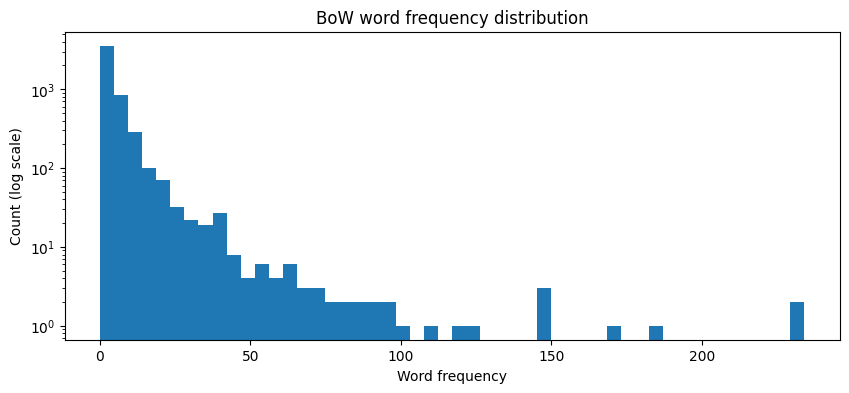

In [30]:
import matplotlib.pyplot as plt
word_counts = bow_stop.toarray()[:500].sum(axis=0)
plt.figure(figsize=(10, 4))
plt.hist(word_counts, bins=50, log=True)
plt.xlabel("Word frequency")
plt.ylabel("Count (log scale)")
plt.title("BoW word frequency distribution")
plt.show()

In [31]:
bow_df = pd.DataFrame(
    bow_stop[:5].toarray(),
    columns=vectorizer_stop.get_feature_names_out()
)
bow_df.head()

,000,10,100,10th,11,11th,12,12th,13,13th,...,zenon,zeon,zero,zhang,zodiac,zombie,zombies,zone,zoo,zorori
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,4,0,0,0,0,0,0,0,0,0


In [32]:
class BoWRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids   = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        known     = [r for r in raw_ids if r in _synopsis_df.index]
        anime_sub = _synopsis_df.loc[known]

        vectorizer       = CountVectorizer(stop_words="english", max_features=5000)
        bow_matrix       = vectorizer.fit_transform(anime_sub["sypnopsis"])
        self.feat_matrix = normalize(bow_matrix, norm="l2")
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(anime_sub.index)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid       = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                result = self.feat_matrix[test_idxs].dot(self.feat_matrix[rated_idxs].T)
                sims   = result.toarray() if hasattr(result, "toarray") else np.asarray(result)

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = np.asarray(self.feat_matrix[self.item_idx[raw_i]].todense()).flatten()
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = np.asarray(self.feat_matrix[rated_idxs].dot(vec_i)).flatten()
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [33]:
bow = BoWRecommender()

bow.fit(trainset)
acc = eval_accuracy(bow.test(testset))

bow.fit(trainset_cov)
cov_preds = bow.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["BoW"] = {**acc, **cov}
pd.Series(results["BoW"])

RMSE                      1.4631
MAE                       1.1058
Precision@10              0.7664
Recall@10                 0.5019
NDCG@10                   0.9591
Coverage                 12.7500
Personalization           0.9627
Intra-List Similarity     0.2227
dtype: float64

In [34]:
cv_results = cross_validate(
    BoWRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

,test_rmse,test_mae,train_rmse,train_mae
mean,1.464582,1.106079,1.29110,0.969896
std,0.002306,0.001406,0.00061,0.000429


## TF-IDF Recommender

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(_synopsis_df["sypnopsis"])
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("BoW matrix shape:   ", bow_stop.shape)

TF-IDF matrix shape: (16214, 5000)
BoW matrix shape:    (16214, 5000)


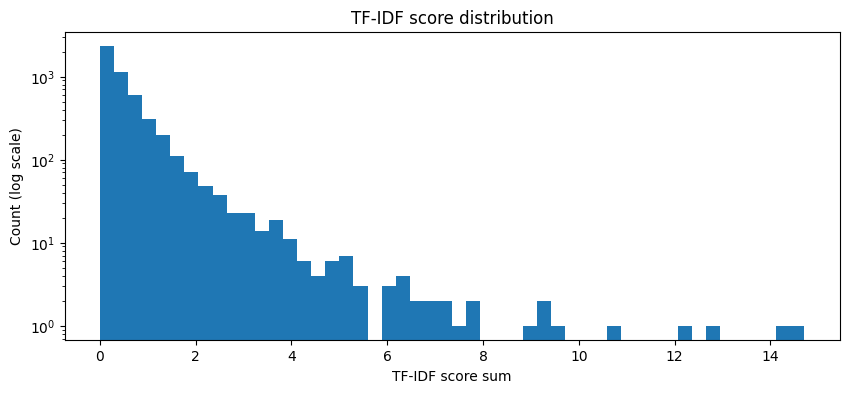

In [36]:
tfidf_scores = tfidf_matrix[:500].toarray().sum(axis=0)
plt.figure(figsize=(10, 4))
plt.hist(tfidf_scores, bins=50, log=True)
plt.xlabel("TF-IDF score sum")
plt.ylabel("Count (log scale)")
plt.title("TF-IDF score distribution")
plt.show()

In [37]:
tfidf_df = pd.DataFrame(
    tfidf_matrix[:5].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.head()

,000,10,100,10th,11,11th,12,12th,13,13th,...,zenon,zeon,zero,zhang,zodiac,zombie,zombies,zone,zoo,zorori
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.392828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.536027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Lemmatization

*[Your note on why lemmatization was not used]*

In [38]:
class TFIDFRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids   = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        known     = [r for r in raw_ids if r in _synopsis_df.index]
        anime_sub = _synopsis_df.loc[known]

        vect             = TfidfVectorizer(stop_words="english", max_features=5000)
        tfidf_mat        = vect.fit_transform(anime_sub["sypnopsis"])
        self.feat_matrix = normalize(tfidf_mat, norm="l2")
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(anime_sub.index)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid       = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                result = self.feat_matrix[test_idxs].dot(self.feat_matrix[rated_idxs].T)
                sims   = result.toarray() if hasattr(result, "toarray") else np.asarray(result)

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = np.asarray(self.feat_matrix[self.item_idx[raw_i]].todense()).flatten()
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = np.asarray(self.feat_matrix[rated_idxs].dot(vec_i)).flatten()
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [39]:
tfidf = TFIDFRecommender()

tfidf.fit(trainset)
acc = eval_accuracy(tfidf.test(testset))

tfidf.fit(trainset_cov)
cov_preds = tfidf.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["TF-IDF"] = {**acc, **cov}
pd.Series(results["TF-IDF"])

RMSE                      1.4517
MAE                       1.0943
Precision@10              0.7746
Recall@10                 0.5043
NDCG@10                   0.9633
Coverage                 13.4200
Personalization           0.9654
Intra-List Similarity     0.2206
dtype: float64

In [40]:
cv_results = cross_validate(
    TFIDFRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

,test_rmse,test_mae,train_rmse,train_mae
mean,1.453174,1.094687,1.198056,0.893540
std,0.002152,0.001326,0.000671,0.000464


## BERT Recommender

In [41]:
from sentence_transformers import SentenceTransformer

_bert_model = SentenceTransformer("all-MiniLM-L6-v2")
_bert_cache = {}

synopses_all = _synopsis_df["sypnopsis"].tolist()
ids_all      = _synopsis_df.index.tolist()
embeddings_all = _bert_model.encode(synopses_all, show_progress_bar=True, batch_size=64)
for mid, emb in zip(ids_all, embeddings_all):
    _bert_cache[mid] = emb

print("BoW matrix shape:        ", bow_stop.shape)
print("TF-IDF matrix shape:     ", tfidf_matrix.shape)
print("BERT embeddings shape:   ", embeddings_all.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/254 [00:00<?, ?it/s]

BoW matrix shape:         (16214, 5000)
TF-IDF matrix shape:      (16214, 5000)
BERT embeddings shape:    (16214, 384)


In [42]:
embeddings_df = pd.DataFrame(embeddings_all, index=_synopsis_df.index)
embeddings_df.head()

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
MAL_ID,,,,,,,,,,,,,,,,,,,,,
1,-0.079320,-0.031990,-0.054948,-0.027695,0.019967,0.048179,0.058222,0.011789,-0.004828,-0.019782,...,0.034524,-0.006011,-0.038581,0.065660,0.007235,-0.020745,0.029754,-0.067886,0.012642,-0.042742
5,-0.074500,0.069052,0.016639,0.036340,0.081231,0.009334,0.036593,0.076075,-0.034812,0.020394,...,0.062196,-0.055485,-0.024611,0.042608,-0.021842,0.026708,0.037085,-0.180263,-0.014235,0.019607
6,0.018597,0.089144,-0.042042,0.016114,0.058198,0.040770,0.143477,0.034466,-0.003781,0.033659,...,0.030565,0.009016,-0.077341,-0.015655,-0.012503,-0.015565,0.007478,-0.124750,0.020182,-0.040823
7,-0.030945,-0.006160,-0.057169,0.052504,0.012212,0.013273,0.159179,0.052044,0.042337,0.012396,...,-0.046539,0.042434,0.029671,-0.044752,0.002298,-0.040043,0.013019,-0.056087,0.072019,-0.038276
8,-0.035770,0.067944,-0.100477,-0.044423,0.034286,0.076920,0.033770,0.010735,-0.011177,-0.001312,...,-0.058995,-0.000684,-0.064772,0.021189,-0.038982,0.013368,0.041429,-0.068741,0.075173,-0.000356


In [43]:
class BERTRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        known   = [r for r in raw_ids if r in _bert_cache]

        feat_matrix = np.array([_bert_cache[r] for r in known])
        norms = np.linalg.norm(feat_matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1
        self.feat_matrix = feat_matrix / norms
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(known)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid       = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                sims = self.feat_matrix[test_idxs] @ self.feat_matrix[rated_idxs].T

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = self.feat_matrix[self.item_idx[raw_i]]
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = self.feat_matrix[rated_idxs] @ vec_i
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [44]:
bert = BERTRecommender()

bert.fit(trainset)
acc = eval_accuracy(bert.test(testset))

bert.fit(trainset_cov)
cov_preds = bert.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["BERT"] = {**acc, **cov}
pd.Series(results["BERT"])

RMSE                      1.4848
MAE                       1.1255
Precision@10              0.7616
Recall@10                 0.5011
NDCG@10                   0.9581
Coverage                 11.5300
Personalization           0.9572
Intra-List Similarity     0.2512
dtype: float64

In [45]:
cv_results = cross_validate(
    BERTRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

,test_rmse,test_mae,train_rmse,train_mae
mean,1.487058,1.126429,1.448358,1.098418
std,0.002727,0.001546,0.000618,0.000453


## NER Recommender (Experimental)

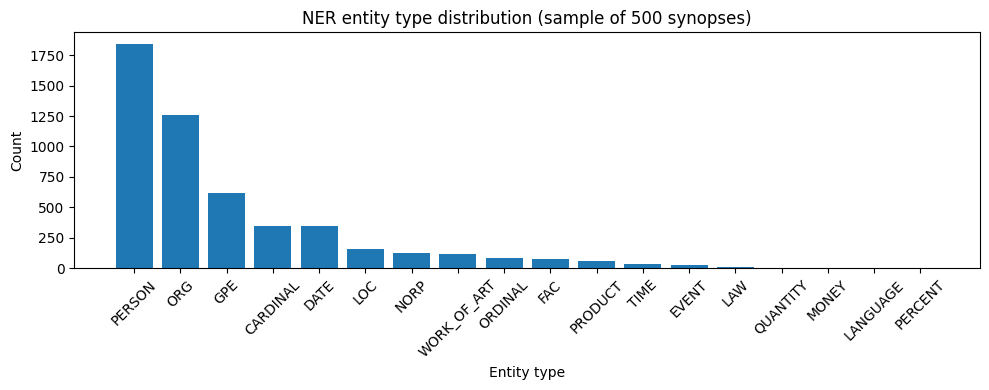

Avg entities per synopsis: 10.21
Max entities per synopsis: 26
Synopses with 0 entities:  0


In [46]:
import spacy
nlp_ner = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp_ner(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

sample_entities = _synopsis_df["sypnopsis"].head(500).apply(extract_entities)

import matplotlib.pyplot as plt
from collections import Counter

all_labels = [label for ents in sample_entities for _, label in ents]
label_counts = Counter(all_labels)
labels, counts = zip(*sorted(label_counts.items(), key=lambda x: -x[1]))
plt.figure(figsize=(10, 4))
plt.bar(labels, counts)
plt.xlabel("Entity type")
plt.ylabel("Count")
plt.title("NER entity type distribution (sample of 500 synopses)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

entity_counts_per_doc = sample_entities.apply(len)
print("Avg entities per synopsis:", round(entity_counts_per_doc.mean(), 2))
print("Max entities per synopsis:", entity_counts_per_doc.max())
print("Synopses with 0 entities: ", (entity_counts_per_doc == 0).sum())

In [47]:
entity_strings = _synopsis_df["sypnopsis"].head(500).apply(
    lambda t: " ".join([e.text for e in nlp_ner(t).ents])
)
pd.DataFrame({"synopsis": _synopsis_df["sypnopsis"].head(5),
              "entities": entity_strings.head(5)})

,synopsis,entities
MAL_ID,,
1,"In the year 2071, humanity has colonized sever...",the year 2071 Earth The Inter Solar System Pol...
5,"other day, another bounty—such is the life of ...",Bebop Faye Mars three hundred million Bebop Ed...
6,"Vash the Stampede is the man with a $$60,000,0...","Stampede $$60,000,000,000 The Humanoid Typhoon..."
7,ches are individuals with special powers like ...,Robin 15-year-old Italy Japan STN Japan Divisi...
8,It is the dark century and the people are suff...,the dark century Vandel The Vandel Busters the...


In [48]:
def get_entity_string(text):
    doc = nlp_ner(text)
    return " ".join([ent.text for ent in doc.ents])

_ner_strings = _synopsis_df["sypnopsis"].apply(get_entity_string)

from sklearn.feature_extraction.text import CountVectorizer as CV
ner_vect = CV(max_features=5000)
ner_mat  = ner_vect.fit_transform(_ner_strings)
print("NER matrix shape:", ner_mat.shape)
print("BoW matrix shape:", bow_stop.shape)

NER matrix shape: (16214, 5000)
BoW matrix shape: (16214, 5000)


In [49]:
class NERRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids   = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        known     = [r for r in raw_ids if r in _synopsis_df.index]
        anime_sub = _synopsis_df.loc[known]

        ner_texts        = anime_sub["sypnopsis"].apply(get_entity_string)
        vect             = CountVectorizer(max_features=5000)
        ner_matrix       = vect.fit_transform(ner_texts)
        self.feat_matrix = normalize(ner_matrix, norm="l2")
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(anime_sub.index)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid       = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                result = self.feat_matrix[test_idxs].dot(self.feat_matrix[rated_idxs].T)
                sims   = result.toarray() if hasattr(result, "toarray") else np.asarray(result)

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = np.asarray(self.feat_matrix[self.item_idx[raw_i]].todense()).flatten()
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = np.asarray(self.feat_matrix[rated_idxs].dot(vec_i)).flatten()
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [50]:
ner = NERRecommender()

ner.fit(trainset)
acc = eval_accuracy(ner.test(testset))

ner.fit(trainset_cov)
cov_preds = ner.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["NER"] = {**acc, **cov}
pd.Series(results["NER"])

RMSE                      1.4951
MAE                       1.1192
Precision@10              0.7512
Recall@10                 0.4975
NDCG@10                   0.9564
Coverage                 17.9000
Personalization           0.9825
Intra-List Similarity     0.2337
dtype: float64

In [51]:
cv_results = cross_validate(
    NERRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

KeyboardInterrupt: 

*[I need to write here about the limitations of NER]*

# Model Comparison

In [52]:
results_df = pd.DataFrame(results).T
results_df

,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage,Personalization,Intra-List Similarity
Popular,1.6907,1.2893,0.8003,0.5136,0.9728,0.65,0.1593,0.3046
Random,2.4038,1.9041,0.7183,0.4844,0.9472,38.98,0.9984,0.1925
Metadata,1.4589,1.1047,0.7786,0.5076,0.9618,12.21,0.9074,0.2817
BoW,1.4631,1.1058,0.7664,0.5019,0.9591,12.75,0.9627,0.2227
TF-IDF,1.4517,1.0943,0.7746,0.5043,0.9633,13.42,0.9654,0.2206
BERT,1.4848,1.1255,0.7616,0.5011,0.9581,11.53,0.9572,0.2512
NER,1.4951,1.1192,0.7512,0.4975,0.9564,17.90,0.9825,0.2337


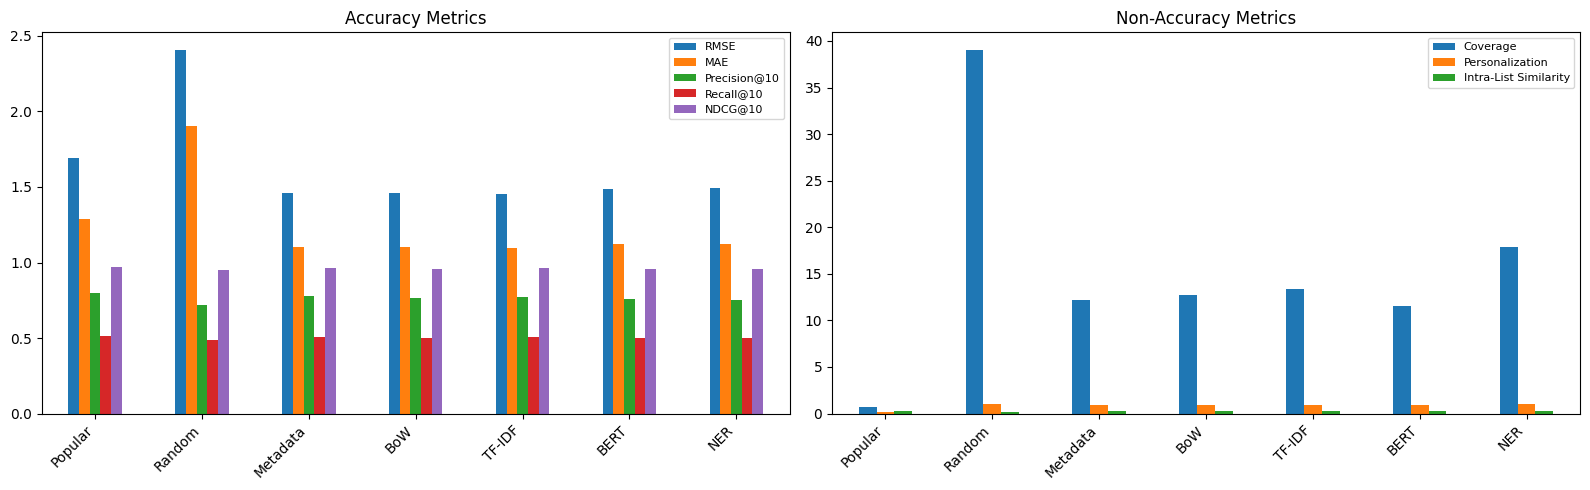

In [53]:
import matplotlib.pyplot as plt

accuracy_metrics  = ["RMSE", "MAE", "Precision@10", "Recall@10", "NDCG@10"]
coverage_metrics  = ["Coverage", "Personalization", "Intra-List Similarity"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

results_df[accuracy_metrics].plot(kind="bar", ax=axes[0])
axes[0].set_title("Accuracy Metrics")
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].legend(loc="upper right", fontsize=8)

results_df[coverage_metrics].plot(kind="bar", ax=axes[1])
axes[1].set_title("Non-Accuracy Metrics")
axes[1].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()